# Chambolle–Pock Primal–Dual Splitting

Implement a primal–dual algorithm for total-variation inpainting and denoising. The complete examples make the image gradient, its adjoint, and each proximity operator explicit, and check the result using feasibility and a primal–dual gap.


## Run this tour

Run the cells in order with a Python 3 kernel. The first cell locates the companion data and toolbox and installs missing dependencies when needed. All worked examples include their implementation directly in this notebook. Random seeds make comparisons reproducible; you can change them to explore other samples.


In [1]:
# Locate the companion toolbox locally, or fetch it for a standalone/Colab copy.
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

working = Path.cwd()
candidates = [working, working / "python", working.parent / "python"]
python_dir = next((p for p in candidates if (p / "nt_toolbox").is_dir()), None)
if python_dir is None:
    checkout = working / "numerical-tours-support"
    if not checkout.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "master",
                "https://github.com/gpeyre/numerical-tours.git",
                str(checkout),
            ],
            check=True,
        )
    python_dir = checkout / "python"
os.chdir(python_dir)
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))
requirements = python_dir / "requirements.txt"
if any(
    importlib.util.find_spec(name) is None
    for name in [
        "numpy",
        "scipy",
        "matplotlib",
        "skimage",
        "sklearn",
        "pywt",
        "ipywidgets",
        "cvxpy",
        "skfmm",
        "autograd",
        "progressbar",
        "celer",
    ]
):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(requirements)], check=True
    )

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "image.cmap": "gray",
    }
)
%matplotlib inline

$\newcommand{\umin}[1]{\underset{#1}{\min}\;}$


We have seen in the lab 3 that total variation denoising can be performed using the dual forward-backward algorithm. But the setting is restrictive: this algorithm cannot be applied to general inverse problems. 

This tour explores the primal-dual proximal splitting algorithm proposed in 

A. Chambolle and T. Pock, "A First-order primal-dual algorithm for convex problems with application to imaging,"
_Journal of Mathematical Imaging and Vision_,
vol. 40, no. 1, 2011

and further analyzed and extended in 

L. Condat, "A primal-dual splitting method for convex optimization involving Lipschitzian, proximable and linear composite terms," _J. Optimization Theory and Applications_, vol. 158, no. 2, 2013.


Convex Optimization with a Primal-Dual Scheme
---------------------------------------------

We consider a (primal) optimization problem of the form
$$ \umin{x} f(x) + g(Lx) $$
where $f$ and $g$ are convex functions, whose proximity operators can be computed, and $L$
is a linear operator.

The dual problem is 

$$ \umin{u} f^*(-L^*u) + g^*(u) $$

The (relaxed) Chambolle-Pock algorithm takes initial estimates $x^{(0)}$ and $u^{(0)}$ of the primal and dual solutions, a parameter $\tau>0$, a second parameter $0<\sigma\leq 1/(\tau\|L\|^2)$, a relaxation parameter $0<\rho<2$, and iterates, for $k=1,2,\ldots$
$$ \left|\begin{array}{l}
\tilde{x}^{(k)} = \mathrm{prox}_{\tau f}(  x^{(k-1)}-\tau L^*(u^{(k-1)}) ) \\
 \tilde{u}^{(k)} = \mathrm{prox}_{\sigma g^*}( u^{(k-1)}+ \sigma L(2\tilde{x}^{(k)}-x^{(k-1)}) \\
 x^{(k)}= x^{(k-1)} + \rho (\tilde{x}^{(k)}-x^{(k-1)})\\
 u^{(k)}= u^{(k-1)} + \rho (\tilde{u}^{(k)}-u^{(k-1)})
 \end{array}\right.$$
 
 Then, $x^{(k)}$ converges to a primal solution $x^\star$ and $u^{(k)}$ converges to a dual solution $u^\star$.
 
 In practice, like for the Douglas-Rachford algorithm, it is always interesting to take $\rho$ close to $2$, e.g. $\rho=1.9$, instead of $\rho=1$ like in the paper of Chambolle & Pock. Also, for fixed $\tau$, the higher $\sigma$, the better; so, one can set $\sigma=1/(\tau\|L\|^2)$, which leaves only the parameter $\tau$ to tune.

With this choice of $\sigma$, the algorithm exactly reverts to the Douglas-Rachford algorithm when $L=\mathrm{Id}$ (replacing $\sigma$ by $1/\tau$ in the algorithm). So, it is a natural extension of the latter.


We recall that being able to compute the proximity operator of $f^*$ is
equivalent to being able to compute the proximity operator of $f$, thanks to the Moreau identity
$$ x = \mathrm{prox}_{\gamma f^*}(x) + \gamma \mathrm{prox}_{f/\gamma}(x/\gamma) $$


Image Inpainting
---------------------------------------------

Like in the lab 1, we want to reconstruct an estimate of the Lena image from a random subset of its pixels. So, we want to solve 
$$\umin{x} \mathrm{TV}(x)\quad\mbox{s.t.}\quad Ax=b,$$
where we keep the notations of the labs 1 and 3: $A$ is the degradation operator which multiplies the image by a binary mask and $\mathrm{TV}$ is the total variation.


## A complete primal–dual implementation

We use periodic finite differences, with `DT` defined as the exact adjoint of `D`. The dual projection acts independently at each pixel. Choosing $\tau\sigma\|D\|^2<1$ with $\|D\|^2\leq8$ gives the standard unrelaxed Chambolle–Pock scheme a safe step size. The following implementation exposes every update; no external exercise code is required.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from nt_toolbox.signal import load_image


def D(x):
    return np.stack((np.roll(x, -1, axis=0) - x, np.roll(x, -1, axis=1) - x), axis=-1)


def DT(u):
    return (
        np.roll(u[..., 0], 1, axis=0)
        - u[..., 0]
        + np.roll(u[..., 1], 1, axis=1)
        - u[..., 1]
    )


def tv(x):
    return np.linalg.norm(D(x), axis=-1).sum()


def primal_dual(prox_f, x0, weight=1.0, tau=0.3, steps=600):
    sigma = 0.99 / (8 * tau)
    x = x0.copy()
    x_bar = x.copy()
    u = np.zeros((*x.shape, 2))
    history = []
    for _ in range(steps):
        u = u + sigma * D(x_bar)
        u = u / np.maximum(1, np.linalg.norm(u, axis=-1, keepdims=True) / weight)
        x_next = prox_f(x - tau * DT(u), tau)
        x_bar = 2 * x_next - x
        x = x_next
        history.append(tv(x))
    return x, u, np.asarray(history)


rng = np.random.default_rng(0)
clean = load_image("nt_toolbox/data/lena.bmp", 128)
a = rng.normal(size=clean.shape)
b = rng.normal(size=(*clean.shape, 2))
assert np.allclose(np.sum(D(a) * b), np.sum(a * DT(b)))

## Recovering missing pixels

The data constraint fixes observed pixels exactly. Its proximity operator simply puts these pixels back after every primal step. We compare several step sizes and then contrast total variation with a quadratic smoothness penalty: TV can retain sharp boundaries, whereas quadratic regularization tends to smooth them.


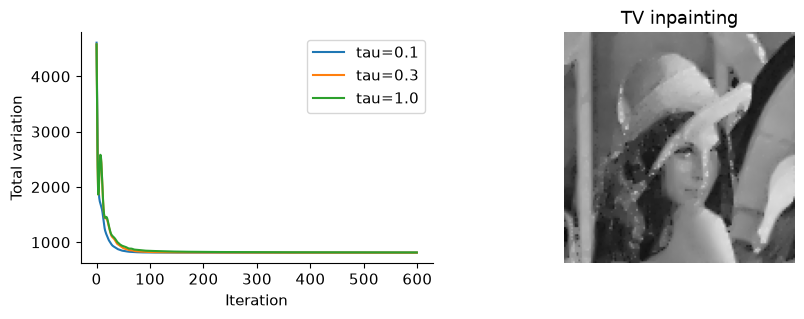

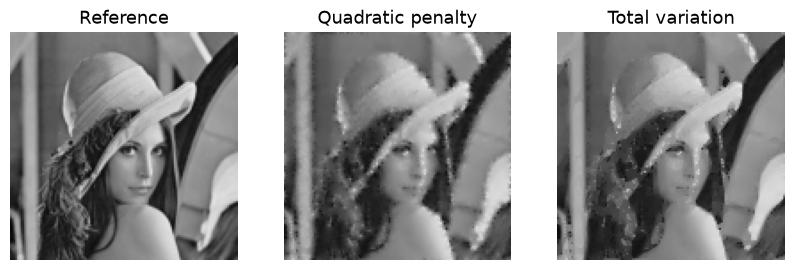

In [3]:
mask = rng.random(clean.shape) < 0.3
y = mask * clean
prox_data = lambda x, tau: np.where(mask, y, x)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for tau in [0.1, 0.3, 1.0]:
    restored, dual, history = primal_dual(prox_data, y, tau=tau)
    axes[0].plot(history, label=f"tau={tau}")
axes[0].set(xlabel="Iteration", ylabel="Total variation")
axes[0].legend()
quadratic = y.copy()
for _ in range(600):
    quadratic = prox_data(quadratic - 0.24 * DT(D(quadratic)), 1)
axes[1].imshow(restored, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("TV inpainting")
axes[1].axis("off")
assert np.allclose(restored[mask], clean[mask])
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, image, title in zip(
    axes,
    [clean, quadratic, restored],
    ["Reference", "Quadratic penalty", "Total variation"],
):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

## Denoising and checking optimality

For a quadratic data term, the primal proximity operator is a weighted average with the noisy image. The primal–dual gap checks both feasibility and optimality: it is nonnegative up to roundoff and approaches zero as the iterates converge. We also compare with projected gradient descent on the dual problem.


Primal–dual gap: 0.002237
Difference from dual forward–backward: 0.000103


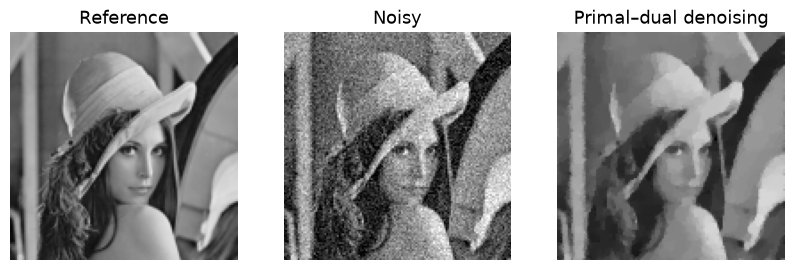

In [4]:
noisy = clean + 0.08 * rng.normal(size=clean.shape)
weight = 0.08
prox_denoise = lambda x, tau: (x + tau * noisy) / (1 + tau)
denoised, u, _ = primal_dual(prox_denoise, noisy, weight=weight)
primal_energy = 0.5 * np.sum((denoised - noisy) ** 2) + weight * tv(denoised)
dual_energy = 0.5 * np.sum(noisy**2) - 0.5 * np.sum((noisy - DT(u)) ** 2)
gap = primal_energy - dual_energy
print(f"Primal–dual gap: {gap:.4g}")
assert gap >= -1e-8
assert np.mean((denoised - clean) ** 2) < np.mean((noisy - clean) ** 2)
v = np.zeros_like(u)
for _ in range(600):
    v = v + 0.24 * D(noisy - DT(v))
    v /= np.maximum(1, np.linalg.norm(v, axis=-1, keepdims=True) / weight)
dual_fb_image = noisy - DT(v)
print(
    f"Difference from dual forward–backward: {np.linalg.norm(dual_fb_image - denoised) / np.linalg.norm(denoised):.3g}"
)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, image, title in zip(
    axes, [clean, noisy, denoised], ["Reference", "Noisy", "Primal–dual denoising"]
):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

## References and further reading

- Stephen Boyd and Lieven Vandenberghe. [Convex Optimization](https://web.stanford.edu/~boyd/cvxbook/). 2004, Cambridge University Press. Convexity, duality, optimality conditions, and interior-point methods.

- Neal Parikh and Stephen Boyd. [Proximal Algorithms](https://web.stanford.edu/~boyd/papers/prox_algs.html). 2014, Foundations and Trends in Optimization 1(3), 127–239. Proximity operators and splitting methods for nonsmooth objectives.

- Amir Beck and Marc Teboulle. [A Fast Iterative Shrinkage-Thresholding Algorithm for Linear Inverse Problems](https://doi.org/10.1137/080716542). 2009, SIAM Journal on Imaging Sciences 2(1), 183–202. Accelerated proximal gradient descent and its convergence rate.

- Antonin Chambolle and Thomas Pock. [A First-Order Primal-Dual Algorithm for Convex Problems with Applications to Imaging](https://doi.org/10.1007/s10851-010-0251-1). 2011, Journal of Mathematical Imaging and Vision 40, 120–145. Primal–dual splitting for total variation and other composite penalties.

- Laurent Condat. [A Primal–Dual Splitting Method for Convex Optimization Involving Lipschitzian, Proximable and Linear Composite Terms](https://doi.org/10.1007/s10957-012-0245-9). 2013, Journal of Optimization Theory and Applications 158, 460–479. Step-size conditions and a general primal–dual framework.
